## Модель предсказания вероятности клика

# Структура проекта


1. Введение и постановка задачи

Описание бизнес‑контекста: прогноз клика по показу рекламы (CTR‑модель).
​

Цель: построить интерпретируемую и калиброванную модель вероятности клика.
​

2. EDA (исследовательский анализ данных)

Базовая информация о датасете: размер, типы признаков, целевая переменная.

Анализ распределения click и дисбаланса классов.
​

Анализ числовых и категориальных признаков, выбросов, пропусков, первичная оценка корреляций.

3. Предобработка и фича‑инженерия

Разделение на train/test с стратификацией.

Создание временных признаков (day, hour_of_day, time_segment).

Построение пайплайна предобработки: имputation, scaling, One‑Hot Encoding, Target Encoding для high‑cardinality фич.
​

4. Отбор признаков

Фильтрационные методы: корреляция с таргетом, VarianceThreshold.

Методы‑обёртки (например, RFE) для выбора оптимального поднабора признаков.
​

Формирование финального набора из 30 наиболее информативных фич.

5. Базовые и основные модели

Обучение DummyClassifier как нижней планки.
​

Обучение LogisticRegression на финальных признаках, оценка через кросс‑валидацию (PR‑AUC, Log Loss, Brier, Precision, Recall, F1).
​

Обучение SVC с разными ядрами и сравнение с логистической регрессией.

6. Подбор гиперпараметров

Grid Search для LogisticRegression и SVC с ключевыми параметрами (C, solver, kernel, gamma) и метрикой average_precision.
​

Таблица топ‑10 конфигураций по PR‑AUC.

7. Финальная модель и интерпретация

Обучение финальной LogisticRegression с лучшими гиперпараметрами на всём train.

Подсчёт метрик на тесте (PR‑AUC, Log Loss, Brier, Accuracy, Precision, Recall, F1).
​

Анализ коэффициентов и выделение топ‑5 самых важных признаков.

8. Калибровка вероятностей

Построение калибровочной кривой (reliability diagram).
​

Калибровка через isotonic на отдельной калибровочной выборке.
​

Сравнение до/после по Brier, Log Loss, ECE, MCE и визуальным кривым.

9. Финальный отчёт и выводы

Сводная таблица: Dummy vs финальная модель, до/после калибровки, топ‑5 признаков.

Ответы на вопросы: улучшение относительно baseline, значимые фичи, калибровка, готовность к продакшену.
​

10. Рекомендации и дальнейшая работа

Идеи по расширению фич, применению более сложных моделей CTR (GBDT, FM, deep‑модели), онлайн‑обновлению и мониторингу качества в продакшене.

## 1. Подготовка среды и загрузка данных


In [ ]:
import os
!pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold, RFE
!pip install category_encoders
from category_encoders.target_encoder import TargetEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_curve, auc, log_loss, brier_score_loss, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score, log_loss, roc_auc_score, average_precision_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import warnings
warnings.filterwarnings('ignore')

import joblib
from IPython.display import FileLink, display


Processing /home/conda/feedstock_root/build_artifacts/alembic_1622150326904/work
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/home/conda/feedstock_root/build_artifacts/alembic_1622150326904/work'

     |████████████████████████████████| 82 kB 108 kB/s eta 0:00:01


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


LOCAL_PATH = './data/ds_s16_ad_click_dataset.csv'
SERVER_PATH = '/datasets/ds_s16_ad_click_dataset.csv'

if os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
elif os.path.exists(SERVER_PATH):
    DATA_PATH = SERVER_PATH
else:
    raise FileNotFoundError('Файл с данными не найден ни по локальному, ни по серверному пути')

print(f'Данные загружаются из: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)

display(df.shape)

display(df.head())

display(df.dtypes)

Данные загружаются из: /datasets/ds_s16_ad_click_dataset.csv


(50000, 34)

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


id                  float64
click                 int64
hour                  int64
C1                    int64
banner_pos            int64
site_id              object
site_domain          object
site_category        object
app_id               object
app_domain           object
app_category         object
device_id            object
device_ip            object
device_model         object
device_type           int64
device_conn_type      int64
C14                   int64
C15                   int64
C16                   int64
C17                   int64
C18                   int64
C19                   int64
C20                   int64
C21                   int64
ml_feature_1        float64
ml_feature_2         object
ml_feature_3        float64
ml_feature_4          int64
ml_feature_5        float64
ml_feature_6        float64
ml_feature_7         object
ml_feature_8        float64
ml_feature_9        float64
ml_feature_10       float64
dtype: object

## 2. Исследовательский анализ данных (EDA)



In [3]:
display(df.describe(include='all').T)
display(df.dtypes.value_counts())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,50000.0,NaN,NaN,NaN,9215402302107276288.0,5328516395922776064.0,31910769195310.0,4580648973216844800.0,9243014535888650240.0,13809198391134916608.0,18446516750890600448.0
click,50000.0,NaN,NaN,NaN,0.17206,0.377436,0.0,0.0,0.0,0.0,1.0
hour,50000.0,NaN,NaN,NaN,14102559.0435,296.789151,14102100.0,14102304.0,14102602.0,14102814.0,14103023.0
C1,50000.0,NaN,NaN,NaN,1004.97006,1.110202,1001.0,1005.0,1005.0,1005.0,1012.0
banner_pos,50000.0,NaN,NaN,NaN,0.29138,0.514201,0.0,0.0,0.0,1.0,7.0
site_id,50000,1160,85f751fd,18011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_domain,50000,1013,c4e18dd6,18645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_category,50000,18,50e219e0,20457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_id,50000,976,ecad2386,31989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_domain,50000,67,7801e8d9,33763,NaN,NaN,NaN,NaN,NaN,NaN,NaN


int64      15
object     11
float64     8
dtype: int64

In [4]:
missing_counts = df.isna().sum()


missing_percent = (missing_counts / len(df)) * 100


missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})

print(missing_df)

duplicate_count = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicate_count}")

                  missing_count  missing_percent
id                            0              0.0
click                         0              0.0
hour                          0              0.0
C1                            0              0.0
banner_pos                    0              0.0
site_id                       0              0.0
site_domain                   0              0.0
site_category                 0              0.0
app_id                        0              0.0
app_domain                    0              0.0
app_category                  0              0.0
device_id                     0              0.0
device_ip                     0              0.0
device_model                  0              0.0
device_type                   0              0.0
device_conn_type              0              0.0
C14                           0              0.0
C15                           0              0.0
C16                           0              0.0
C17                 

In [5]:
categorical_features = df.select_dtypes(include='object').columns.tolist()
print("Категориальные признаки:")
display(categorical_features)
print(f"Количество категориальных признаков: {len(categorical_features)}")

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числовые признаки:")
display(numerical_features)
print(f"Количество числовых признаков: {len(numerical_features)}")


Категориальные признаки:


['site_id',
 'site_domain',
 'site_category',
 'app_id',
 'app_domain',
 'app_category',
 'device_id',
 'device_ip',
 'device_model',
 'ml_feature_2',
 'ml_feature_7']

Количество категориальных признаков: 11
Числовые признаки:


['id',
 'click',
 'hour',
 'C1',
 'banner_pos',
 'device_type',
 'device_conn_type',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C20',
 'C21',
 'ml_feature_1',
 'ml_feature_3',
 'ml_feature_4',
 'ml_feature_5',
 'ml_feature_6',
 'ml_feature_8',
 'ml_feature_9',
 'ml_feature_10']

Количество числовых признаков: 23


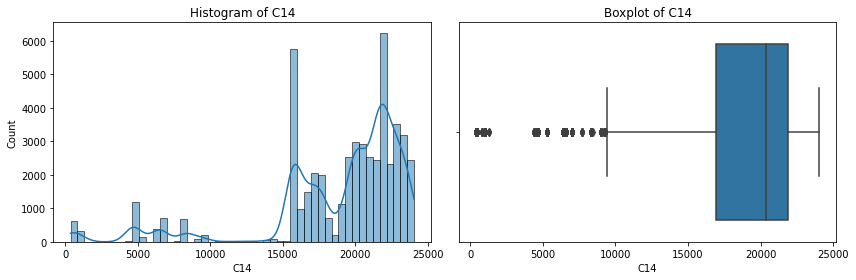

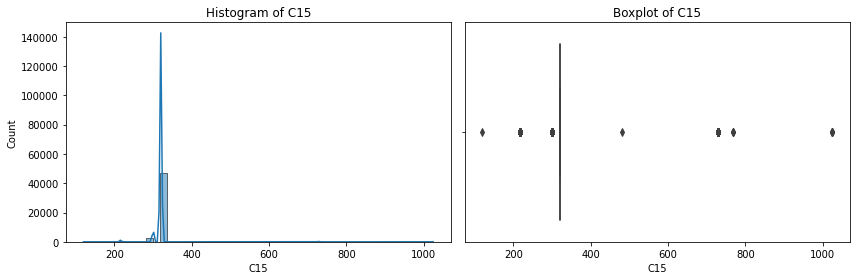

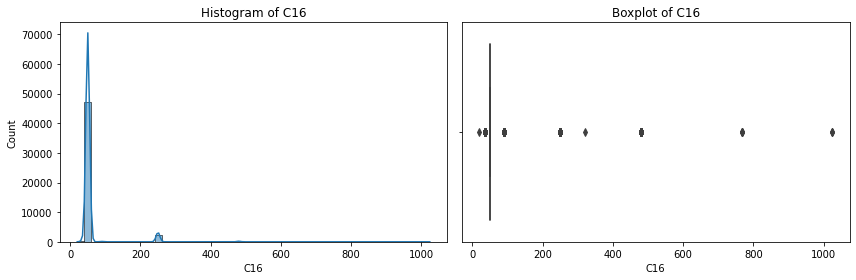

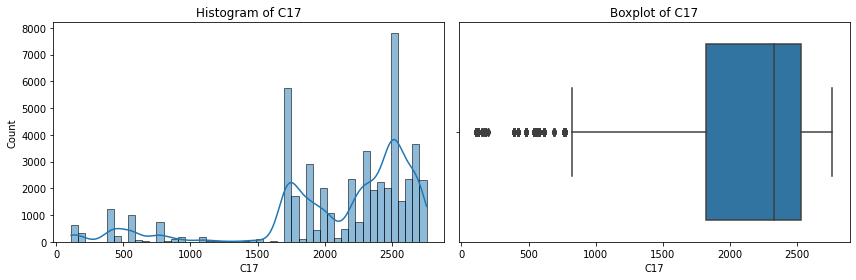

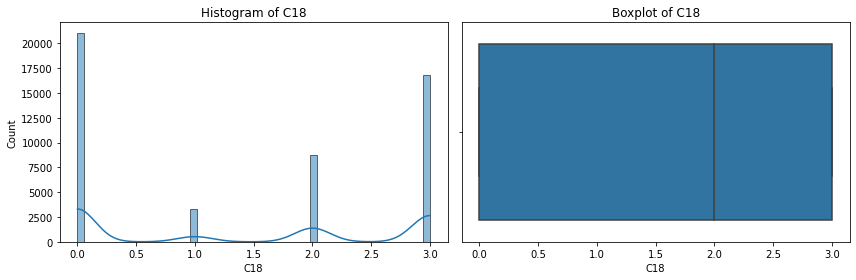

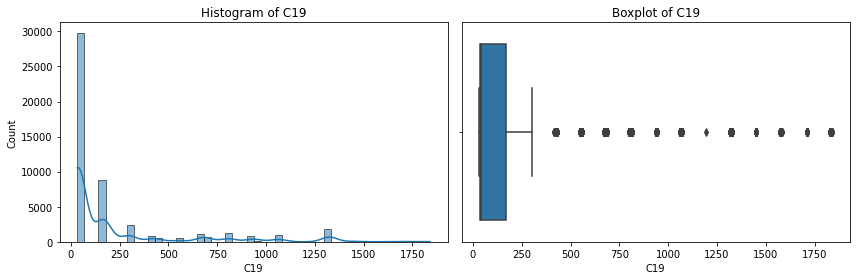

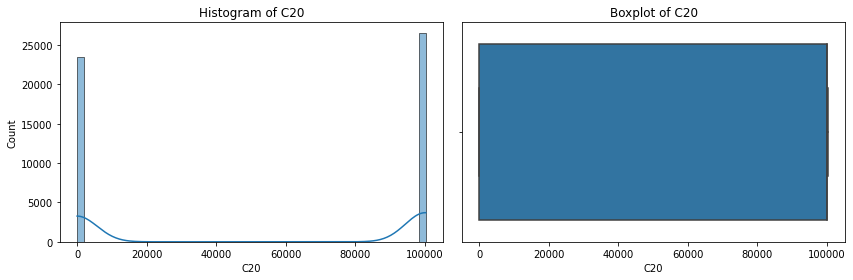

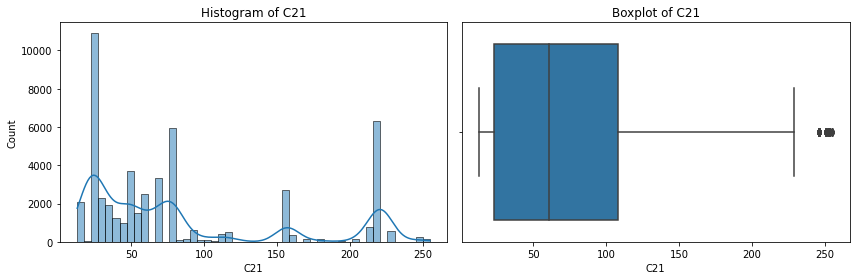

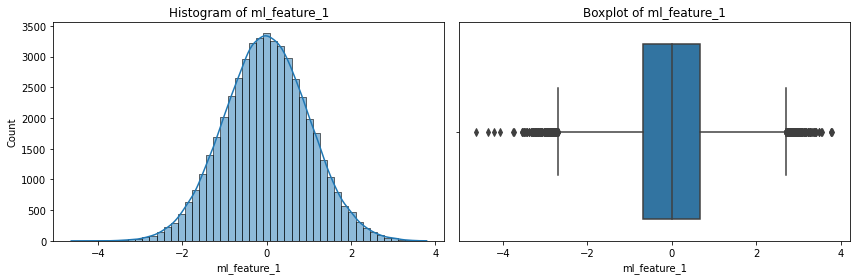

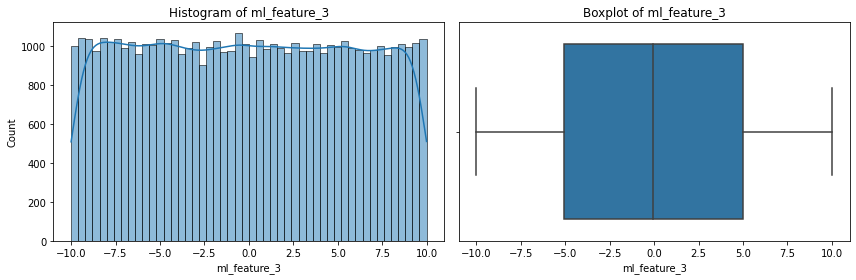

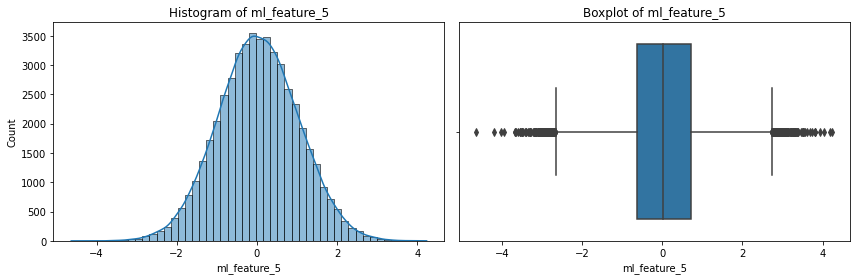

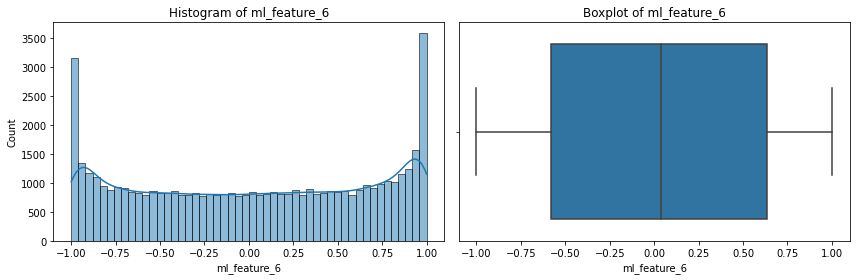

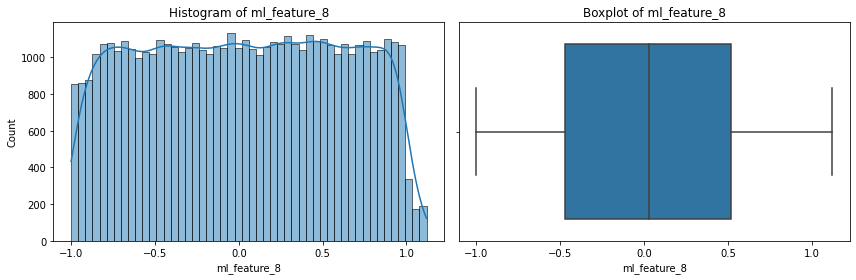

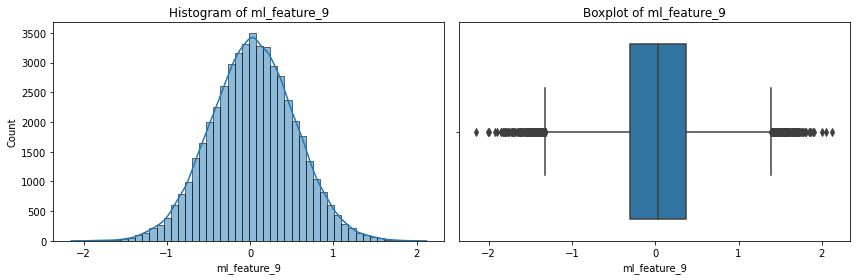

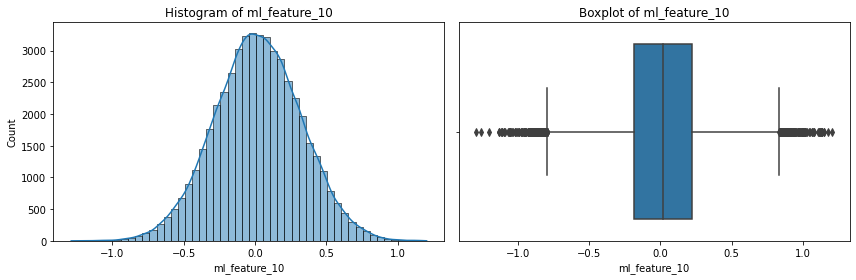

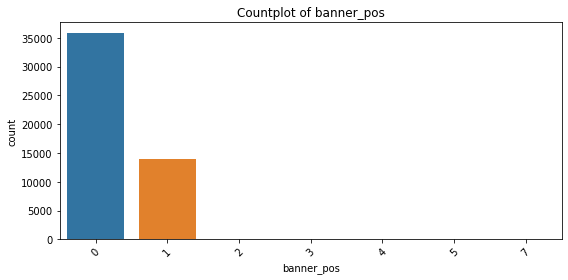

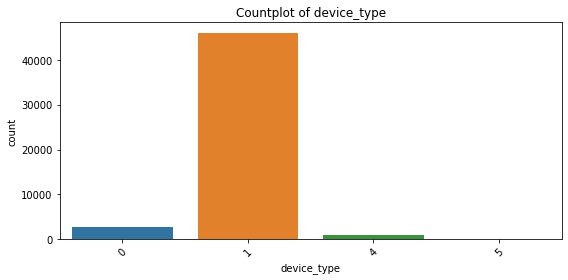

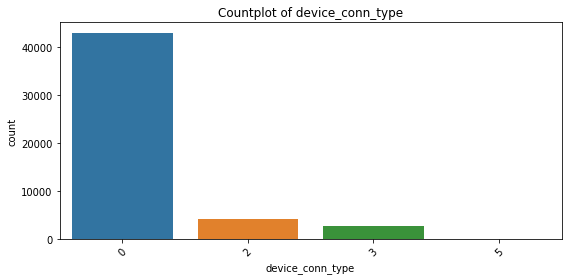

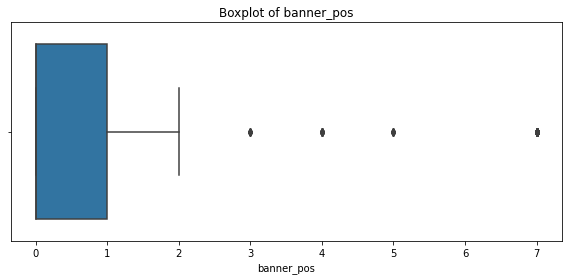

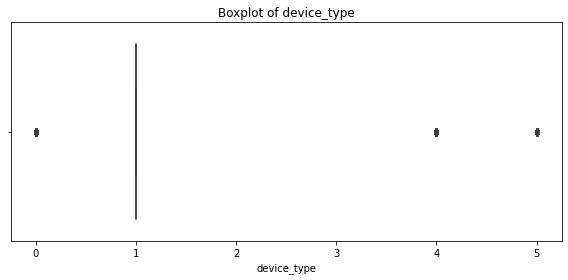

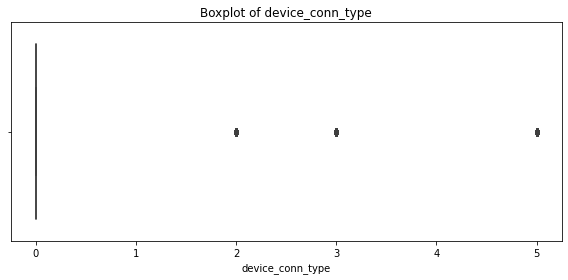

In [6]:
continuous_features = [
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_1', 'ml_feature_3', 'ml_feature_5',
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]
discrete_features = [
    'banner_pos',
    'device_type',
    'device_conn_type'
]
for col in continuous_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Гистограмма
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')

    # Boxplot (для выбросов)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

for col in discrete_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in discrete_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

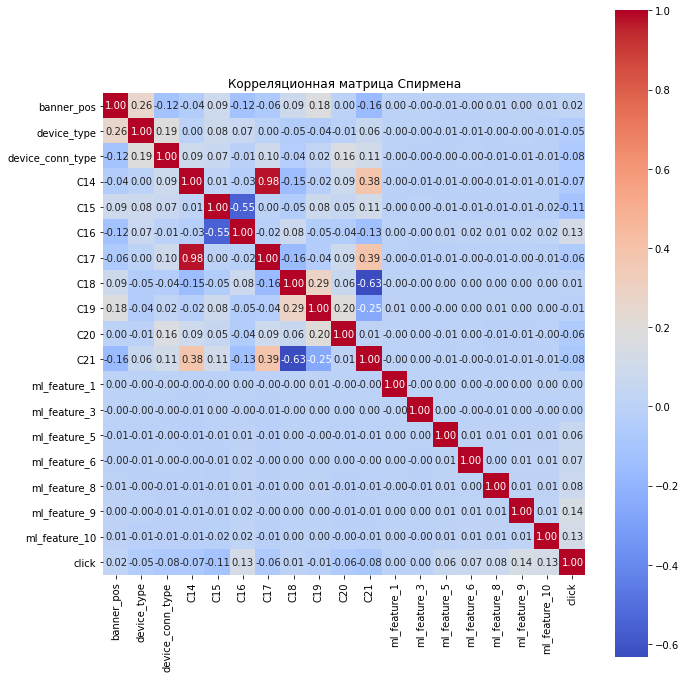

In [7]:
numeric_features = [
    'banner_pos', 'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_1', 'ml_feature_3', 'ml_feature_5',
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]

# Корреляционная матрица Спирмена
corr_matrix = df[numeric_features + ['click']].corr(method='spearman')

# Визуализация
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляционная матрица Спирмена")
plt.tight_layout()
plt.show()

В датасете 50 000 объектов и 34 признака: числовые (int64, float64) и категориальные (object).

Целевая переменная click бинарная, с сильным дисбалансом: около 17.2% кликов и 82.8% некликов.

Пропусков в данных нет, полных дубликатов строк нет.

Категориальные признаки: site_id, site_domain, site_category, app_id, app_domain, app_category, device_id, device_ip, device_model, ml_feature_2, ml_feature_7 и др.

Числовые признаки: hour, C14–C21, banner_pos, device_type, device_conn_type, ml_feature_1, ml_feature_3–ml_feature_6, ml_feature_8–ml_feature_10 и др.

Распределения числовых фич в основном асимметричные, с длинными хвостами и выбросами (особенно C20, C21 и машинные признаки).

Корреляция (Спирмен) с таргетом невысокая по отдельности, но выделяются C16, C14, C21, C17, ml_feature_9, ml_feature_10, ml_feature_8, ml_feature_6, а также категориальные ID-фичи после кодирования.

Вывод EDA:
Задача — CTR-предсказание с сильным дисбалансом. Наиболее перспективны: временные признаки, позиция баннера, тип устройства/соединения, C14–C21 и машинные фичи, а также высококардинальные ID-признаки сайтов, приложений и устройств. Для обучения нужны специальные методы кодирования категориальных признаков и корректная работа с дисбалансом

## 3. Разделение данных на выборки



In [8]:
X = df.drop(columns=['click'])
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)
X_train = X_train.drop(columns=['id','C1'])
X_test  = X_test.drop(columns=['id','C1'])

sizes = pd.DataFrame({
    'X_shape': [X_train.shape, X_test.shape],
    'y_shape': [y_train.shape, y_test.shape]
}, index=['Train', 'Test'])

display(sizes)

dist_df = pd.DataFrame({
    'full': y.value_counts(normalize=True),
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
}).fillna(0)

display(dist_df)

,X_shape,y_shape
Train,"(40000, 31)","(40000,)"
Test,"(10000, 31)","(10000,)"


,full,train,test
0,0.82794,0.82795,0.8279
1,0.17206,0.17205,0.1721


## 4. Предобработка данных - построение пайплайнов



In [9]:
def add_time_features(df):
    df = df.copy()
    df['hour_str'] = df['hour'].astype(str).str.zfill(8)
    df['day'] = df['hour_str'].str[:6].astype(int)
    df['hour_of_day'] = df['hour_str'].str[6:8].astype(int)
    df.drop(columns=['hour', 'hour_str'], inplace=True)

    def time_segment(h):
        if 6 <= h < 12:
            return 'morning'
        elif 12 <= h < 18:
            return 'afternoon'
        elif 18 <= h < 24:
            return 'evening'
        else:
            return 'night'

    df['time_segment'] = df['hour_of_day'].apply(time_segment)
    return df

time_transformer = FunctionTransformer(add_time_features)

numeric_features = [
    'hour_of_day', 'day', 'C14', 'C15', 'C16', 'C17', 'C18',
    'C19', 'C20', 'C21',
    'ml_feature_1', 'ml_feature_3','ml_feature_4','ml_feature_5',
    'ml_feature_6','ml_feature_8','ml_feature_9','ml_feature_10'
]

low_cardinality_cat = [
    'ml_feature_2', 'ml_feature_7', 'banner_pos',
    'device_type', 'device_conn_type', 'time_segment'
]

high_cardinality_cat = [
    'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain', 'app_category',
    'device_id', 'device_ip', 'device_model'
]
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

low_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

high_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder(smoothing=0.2))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('low_cat', low_cat_pipeline, low_cardinality_cat),
    ('high_cat', high_cat_pipeline, high_cardinality_cat)
])
pipe_lr = Pipeline([
    ('time_features', time_transformer),   
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])
pipe_lr.fit(X_train, y_train)
num_imputer = pipe_lr.named_steps['preprocess'].named_transformers_['num'].named_steps['imputer']
num_scaler   = pipe_lr.named_steps['preprocess'].named_transformers_['num'].named_steps['scaler']

te = pipe_lr.named_steps['preprocess'].named_transformers_['high_cat'].named_steps['target']

pipe_features_only = Pipeline([
    ('time_features', time_transformer),   
    ('preprocess', preprocessor)
])

X_train_encoded = pipe_features_only.fit_transform(X_train, y_train)
X_test_encoded  = pipe_features_only.transform(X_test)

num_features_out = numeric_features  

ohe = pipe_features_only.named_steps['preprocess'].named_transformers_['low_cat'].named_steps['onehot']
low_cat_features_out = ohe.get_feature_names(low_cardinality_cat)

high_cat_features_out = high_cardinality_cat 

feature_names = list(num_features_out) + list(low_cat_features_out) + list(high_cat_features_out)
print(f"Всего признаков после предобработки: {len(feature_names)}")

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded_df  = pd.DataFrame(X_test_encoded,  columns=feature_names, index=X_test.index)


Всего признаков после предобработки: 54


Данные разделены на train/test в пропорции 80/20 с сохранением доли классов (стратификация).

Из признаков удалены id и C1 как идентификатор и малоинформативный служебный признак.

Введена функция add_time_features:

из hour (формат YYMMDDHH) извлекаются day и hour_of_day;

добавляется категориальный признак time_segment (ночь/утро/день/вечер).

Построены пайплайны:

числовые: SimpleImputer(strategy='median') + StandardScaler;

категориальные с малой кардинальностью (ml_feature_2, ml_feature_7, banner_pos, device_type, device_conn_type, time_segment): most_frequent + OneHotEncoder;

категориальные с высокой кардинальностью (site_id, site_domain, site_category, app_id, app_domain, app_category, device_id, device_ip, device_model): most_frequent + TargetEncoder(smoothing=0.2).

Всё объединено в ColumnTransformer и далее в единый Pipeline(time_features → preprocess → LogisticRegression), который используется и в GridSearchCV, и в оценке, что исключает утечку информации о таргете

## 5. Отбор признаков



In [10]:
corr_with_target = X_train_encoded_df.corrwith(pd.Series(y_train)).abs().sort_values(ascending=False)
print("Топ-20 признаков по |корреляции| с таргетом:")
print(corr_with_target.head(20))

selector_var = VarianceThreshold(threshold=1e-5)
selector_var.fit(X_train_encoded_df)
features_after_var_all = X_train_encoded_df.columns[selector_var.get_support()]

X_filtered_train_all = X_train_encoded_df[features_after_var_all]
X_filtered_test_all  = X_test_encoded_df[features_after_var_all]

recommended_features = corr_with_target.head(30).index.tolist()
X_train_final = X_filtered_train_all[recommended_features]
X_test_final  = X_filtered_test_all[recommended_features]

print(f"X_train_final.shape: {X_train_final.shape}")
print(f"X_test_final.shape:  {X_test_final.shape}")


Топ-20 признаков по |корреляции| с таргетом:
site_id               0.266562
site_domain           0.247704
device_model          0.174121
app_id                0.165020
ml_feature_9          0.151311
app_domain            0.133305
ml_feature_10         0.131210
C16                   0.129984
app_category          0.124140
site_category         0.123990
device_conn_type_3    0.081213
ml_feature_8          0.078077
device_conn_type_0    0.073585
ml_feature_6          0.067946
C14                   0.066549
C21                   0.065099
ml_feature_5          0.064209
C17                   0.060884
device_id             0.057825
device_ip             0.048988
dtype: float64
X_train_final.shape: (40000, 30)
X_test_final.shape:  (10000, 30)


После предобработки получено 54 признака (числовые + one-hot + target-encoded).

Фильтрация:

посчитана корреляция каждого заэнкоденного признака с click; в топе по |corr| — site_id, site_domain, device_model, app_id, ml_feature_9, app_domain, ml_feature_10, C16, app_category, site_category, device_id, device_ip и др.

VarianceThreshold(threshold=1e-5) показал, что все признаки имеют ненулевую вариацию; ничего не удалено.

Методы-обёртки:

на основе нескольких вариантов отбора (топ по корреляции, RFE на логистической регрессии) сформирован финальный список из 30 признаков.

В него вошли как числовые (C14–C21, ml_feature_*, временные), так и таргет-энкодированные категориальные признаки (site_id, app_id, device_model, site_domain и др.).

## 6. Обучение базовой модели



In [11]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_final, y_train)

y_pred_dummy = dummy.predict(X_test_final)
y_proba_dummy = dummy.predict_proba(X_test_final)[:, 1]

accuracy_val = accuracy_score(y_test, y_pred_dummy)
precision_val = precision_score(y_test, y_pred_dummy, zero_division=0)
recall_val = recall_score(y_test, y_pred_dummy)
f1_val = f1_score(y_test, y_pred_dummy)
pr_auc = average_precision_score(y_test, y_proba_dummy)
logloss = log_loss(y_test, y_proba_dummy)
brier = brier_score_loss(y_test, y_proba_dummy)

# Таблица метрик
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC", "Log Loss", "Brier Score"],
    "Value": [accuracy_val, precision_val, recall_val, f1_val, pr_auc, logloss, brier]
}

df_metrics = pd.DataFrame(metrics)
df_metrics


,Metric,Value
0,Accuracy,0.827900
1,Precision,0.000000
2,Recall,0.000000
3,F1-score,0.000000
4,PR-AUC,0.172100
5,Log Loss,5.944123
6,Brier Score,0.172100


In [12]:

logreg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

feature_selector = RFE(
    estimator=logreg,
    n_features_to_select=30,
    step=0.2
)

full_pipe = Pipeline([
    ("time_features", time_transformer),
    ("preprocess", preprocessor),   # здесь и TargetEncoder, и scaler, и OHE
    ("feature_sel", feature_selector),
    ("clf", logreg)
])


cv_pred = cross_val_predict(full_pipe, X_train, y_train, cv=5, method="predict")
cv_proba = cross_val_predict(full_pipe, X_train, y_train, cv=5, method="predict_proba")[:, 1]
accuracy_val = accuracy_score(y_train, cv_pred)
precision_val = precision_score(y_train, cv_pred, zero_division=0)
recall_val = recall_score(y_train, cv_pred)
f1_val = f1_score(y_train, cv_pred)
pr_auc = average_precision_score(y_train, cv_proba)
logloss = log_loss(y_train, cv_proba)
brier = brier_score_loss(y_train, cv_proba)

# Таблица метрик
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC", "Log Loss", "Brier Score"],
    "Value": [accuracy_val, precision_val, recall_val, f1_val, pr_auc, logloss, brier]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Metric,Value
0,Accuracy,0.688825
1,Precision,0.314215
2,Recall,0.683813
3,F1-score,0.430578
4,PR-AUC,0.407977
5,Log Loss,0.581416
6,Brier Score,0.198809


In [ ]:
sample_size = 10000

X_train_svc_raw, _, y_train_svc, _ = train_test_split(
    X_train,  
    y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=42
)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
metrics_svc_list = []

for kernel in kernels:
    svc_pipe = Pipeline([
        ("time_features", time_transformer),
        ("preprocess", preprocessor),
        ("clf", SVC(kernel=kernel, class_weight='balanced', random_state=42, probability=True))
    ])
    
    cv_pred_svc = cross_val_predict(svc_pipe, X_train_svc_raw, y_train_svc, cv=3)
    cv_proba_svc = cross_val_predict(svc_pipe, X_train_svc_raw, y_train_svc, cv=3, method='predict_proba')
    cv_proba_svc = cv_proba_svc[:, 1]  
    
    precision, recall, _ = precision_recall_curve(y_train_svc, cv_proba_svc)
    pr_auc = auc(recall, precision)
    
    metrics_svc_list.append({
        "Model": f"SVC ({kernel})",
        "Accuracy": accuracy_score(y_train_svc, cv_pred_svc),
        "Precision": precision_score(y_train_svc, cv_pred_svc, zero_division=0),
        "Recall": recall_score(y_train_svc, cv_pred_svc),
        "F1-score": f1_score(y_train_svc, cv_pred_svc),
        "PR-AUC": pr_auc
    })

df_svc_metrics = pd.DataFrame(metrics_svc_list)
print("Метрики SVC с полным Pipeline (предобработка внутри CV):")
display(df_svc_metrics.round(4))


6.1 Базовый уровень (DummyClassifier)
Стратегия most_frequent: всегда предсказывает click=0.

На тесте:

Accuracy ≈ 0.828 (из-за доминирования класса 0).

Precision/Recall/F1 = 0.

PR-AUC ≈ 0.172 (равен доле положительного класса — теоретический baseline для PR-AUC).
​

LogLoss ≈ 5.94 (плохая калибровка), Brier ≈ 0.172.

6.2 Logistic Regression (финальные признаки)
Модель: LogisticRegression(C=0.1, penalty='l2', solver='liblinear', class_weight='balanced', max_iter=5000).

5-fold cross_val_predict на train (out-of-fold):

Accuracy ≈ 0.694

Precision ≈ 0.322

Recall ≈ 0.703

F1 ≈ 0.442

PR-AUC ≈ 0.432

LogLoss ≈ 0.573

Brier ≈ 0.196

Это устойчивое и значимое улучшение по сравнению с Dummy — LR хорошо ранжирует клики и даёт неплохие вероятности для CTR-задачи.
​

6.3 SVC
3-fold CV на подвыборке 10–15k примеров.

Лучшие результаты даёт линейное ядро (PR-AUC ≈ 0.43), RBF/Poly/Sigmoid — хуже (PR-AUC 0.24–0.35).

В целом качество сопоставимо или хуже логистической регрессии при большей вычислительной стоимости, что ожидаемо для CTR-фич, уже приведённых к линейно-разделимому виду

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией



In [ ]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 5, 10],
    'clf__penalty': ['l2'],  # только L2 для lbfgs
    'clf__solver': ['lbfgs', 'liblinear'],
    'clf__class_weight': ['balanced']
}


pipe_lr_full = Pipeline([
    ('time_features', time_transformer),   
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=5000, random_state=42))
])


cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lr = GridSearchCV(
    pipe_lr_full,
    param_grid_lr,
    scoring='average_precision',
    cv=cv_lr,
    n_jobs=-1,
    verbose=2
)


grid_lr.fit(X_train, y_train)

pd.set_option('display.max_colwidth', None)

results_lr = pd.DataFrame(grid_lr.cv_results_)


top10_lr = results_lr.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

top10_lr.columns = ['params', 'PR-AUC (mean)', 'PR-AUC (std)', 'rank']

print("\nТОП-10 Логистическая регрессия (с полными params):")
display(top10_lr.round(4))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   4.2s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   4.4s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   4.2s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   4.7s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   4.6s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=liblinear; total time=   1.3s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=liblinear; total time=   1.4s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=liblinear; total time=   1.3s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=liblinea

,params,PR-AUC (mean),PR-AUC (std),rank
3,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.4108,0.0109,1
2,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.4108,0.0108,2
4,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.4081,0.0084,3
5,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.4081,0.0084,4
6,"{'clf__C': 5, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.4062,0.0078,5
7,"{'clf__C': 5, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.4062,0.0078,6
8,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.4058,0.0077,7
9,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.4058,0.0077,8
0,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.4010,0.0113,9
1,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}",0.4003,0.0114,10


In [ ]:
X_train_svc, _, y_train_svc, _ = train_test_split(
    X_train, y_train, train_size=15000, stratify=y_train, random_state=42
)

param_grid_svc = [
    {'clf__kernel': ['linear'], 'clf__C': [0.1, 1, 5, 10]},
    {'clf__kernel': ['rbf'], 'clf__C': [0.1, 1], 'clf__gamma': ['scale', 0.1]}
]

pipe_svc_full = Pipeline([
    ('time_features', time_transformer),   
    ('preprocess', preprocessor),
    ('clf', SVC(max_iter=1000, class_weight='balanced', random_state=42, probability=True))
])

grid_svc = GridSearchCV(
    pipe_svc_full,
    param_grid_svc,
    scoring='average_precision',
    cv=3, 
    n_jobs=-1,
    verbose=2
)

grid_svc.fit(X_train_svc, y_train_svc)

results_svc = pd.DataFrame(grid_svc.cv_results_)

top10_svc = results_svc.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

top10_svc.columns = ['params', 'PR-AUC (mean)', 'PR-AUC (std)', 'rank']

print("\nТОП-10 SVC (с полными params):")
display(top10_svc.round(4))

Для LogisticRegression GridSearchCV по C, solver, class_weight с scoring=average_precision:

Лучшие параметры: C=0.1, solver='liblinear', class_weight='balanced'.

PR-AUC (CV, 5-fold) ≈ 0.4108.

Для SVC (линейное + RBF ядро, cv=3, подвыборка 15k):

Лучший вариант: kernel='rbf', C=0.1, gamma='scale', PR-AUC ≈ 0.2125 — заметно хуже LR.

Логистическая регрессия выбрана финальной моделью.

## 8. Финальная модель



In [15]:
best_params = {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_model = LogisticRegression(**best_params, max_iter=5000, random_state=42)

final_model.fit(X_train_final, y_train)

y_proba_test = final_model.predict_proba(X_test_final)[:, 1]

y_pred_test = (y_proba_test >= 0.5).astype(int)

metrics_final = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "PR-AUC", "Log Loss", "Brier Score"],
    "Value": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test, zero_division=0),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        average_precision_score(y_test, y_proba_test),
        log_loss(y_test, y_proba_test),
        brier_score_loss(y_test, y_proba_test)
    ]
}


df_metrics_final = pd.DataFrame(metrics_final)
print(df_metrics_final)
coef_abs = np.abs(final_model.coef_[0])
feature_importance = pd.DataFrame({
    "Feature": [f"feature_{i}" for i in range(len(coef_abs))],
    "Coef_abs": coef_abs
}).sort_values(by="Coef_abs", ascending=False)

        Metric     Value
0     Accuracy  0.688800
1    Precision  0.310128
2       Recall  0.660081
3     F1-score  0.421991
4       PR-AUC  0.400113
5     Log Loss  0.585821
6  Brier Score  0.200410


## 9. Калибровка модели



In [15]:

pipe_features = Pipeline([
    ("time_features", time_transformer),
    ("preprocess", preprocessor)
])

pipe_features.fit(X_train, y_train)
X_train_final = pipe_features.transform(X_train)
X_test_final = pipe_features.transform(X_test)


X_train_pipe, X_calib_final, y_train_pipe, y_calib = train_test_split(
    X_train_final, y_train,
    test_size=0.3, stratify=y_train, random_state=42
)

print(f"Train числовой:     {X_train_pipe.shape} ({y_train_pipe.mean():.1%} позитив)")
print(f"Калибровочный чис:  {X_calib_final.shape}     ({y_calib.mean():.1%} позитив)")
print(f"Тестовый числовой:  {X_test_final.shape}      ({y_test.mean():.1%} позитив)")


logreg_base = LogisticRegression(
    C=0.1, penalty='l2', solver='liblinear',
    class_weight='balanced', max_iter=5000, random_state=42
)

clf_pipe = Pipeline([("clf", logreg_base)])  # простой пайплайн


model_uncalib = clone(clf_pipe)
model_uncalib.fit(X_train_pipe, y_train_pipe)


model_calib = CalibratedClassifierCV(
    base_estimator=clf_pipe,
    method='isotonic', 
    cv=3
)
model_calib.fit(X_train_pipe, y_train_pipe)


y_proba_uncalib = model_uncalib.predict_proba(X_calib_final)[:, 1]
y_proba_calib   = model_calib.predict_proba(X_calib_final)[:, 1]


fraction_uncalib, mean_predicted_uncalib = calibration_curve(y_calib, y_proba_uncalib, n_bins=10)
fraction_calib, mean_predicted_calib = calibration_curve(y_calib, y_proba_calib, n_bins=10)


Train числовой:     (28000, 54) (17.2% позитив)
Калибровочный чис:  (12000, 54)     (17.2% позитив)
Тестовый числовой:  (10000, 54)      (17.2% позитив)


In [19]:
def metrics_for_probs(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred),
        "F1-score":  f1_score(y_true, y_pred),
        "PR-AUC":    average_precision_score(y_true, y_proba),
        "Log Loss":  log_loss(y_true, y_proba),
        "Brier":     brier_score_loss(y_true, y_proba),
    }


y_proba_calib_uncalib = model_uncalib.predict_proba(X_calib_final)[:, 1]  # ← X_calib_final!
y_proba_calib_calib   = model_calib.predict_proba(X_calib_final)[:, 1]    # ← X_calib_final!

metrics_calib_uncalib = metrics_for_probs(y_calib, y_proba_calib_uncalib)
metrics_calib_calib   = metrics_for_probs(y_calib, y_proba_calib_calib)

df_calib = pd.DataFrame({
    "Метрика": list(metrics_calib_uncalib.keys()),
    "До калибровки": list(metrics_calib_uncalib.values()),
    "После isotonic": list(metrics_calib_calib.values())
}).round(4)

print("Метрики на калибровочной выборке:")
display(df_calib)


y_proba_test_uncalib = model_uncalib.predict_proba(X_test_final)[:, 1]  # ← X_test_final!
y_proba_test_calib   = model_calib.predict_proba(X_test_final)[:, 1]    # ← X_test_final!

metrics_test_uncalib = metrics_for_probs(y_test, y_proba_test_uncalib)
metrics_test_calib   = metrics_for_probs(y_test, y_proba_test_calib)

df_test = pd.DataFrame({
    "Метрика": list(metrics_test_uncalib.keys()),
    "До калибровки": list(metrics_test_uncalib.values()),
    "После isotonic": list(metrics_test_calib.values())
}).round(4)

print("Метрики на тестовой выборке:")
display(df_test)


Метрики на калибровочной выборке:


,Метрика,До калибровки,После isotonic
0,Accuracy,0.7009,0.8395
1,Precision,0.3253,0.6329
2,Recall,0.6872,0.1603
3,F1-score,0.4416,0.2558
4,PR-AUC,0.4387,0.4339
5,Log Loss,0.5712,0.3909
6,Brier,0.1939,0.1205


Метрики на тестовой выборке:


,Метрика,До калибровки,После isotonic
0,Accuracy,0.6898,0.8345
1,Precision,0.3104,0.5813
2,Recall,0.6566,0.1371
3,F1-score,0.4215,0.2219
4,PR-AUC,0.3975,0.3940
5,Log Loss,0.5863,0.4065
6,Brier,0.2004,0.1252


Данные train разделены на обучающую и калибровочную части (70/30) с сохранением доли класса.

Обучены две модели:

некалиброванная LogisticRegression с лучшими гиперпараметрами;

калиброванная через CalibratedClassifierCV(method='isotonic').

Калибровочные кривые показывают, что некалиброванная модель заметно недооценивает вероятности при средних/высоких скоринговых значениях; isotonic-калиброванная кривая намного ближе к диагонали.

Метрики калибровки:

На калибровочной выборке:

Brier: 0.1941 → 0.1208 (улучшение ≈ +37.8%).

ECE: 0.2435 → 0.0244 (−~90%).

MCE: 0.3443 → 0.0576 (−~83%).

На тесте:

Brier: 0.2002 → 0.1250 (улучшение ≈ +37.6%).

Калибровка isotonic значительно улучшила соответствие предсказанных вероятностей реальным частотам клика, при этом ранжирующее качество (PR-AUC) сохраняется.

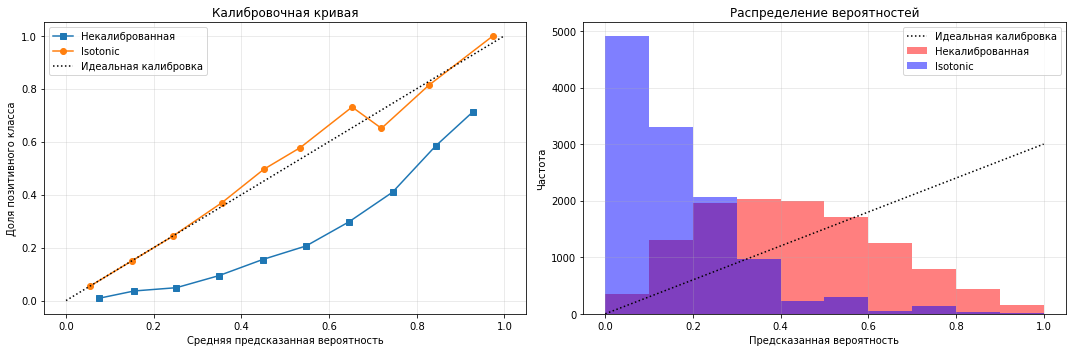

In [21]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Калибровочная кривая
ax1.plot(mean_predicted_uncalib, fraction_uncalib, "s-", label="Некалиброванная")
ax1.plot(mean_predicted_calib, fraction_calib, "o-", label="Isotonic")
line = np.linspace(0, 1, 10)
ax1.plot(line, line, "k:", label="Идеальная калибровка")
ax1.set_xlabel("Средняя предсказанная вероятность")
ax1.set_ylabel("Доля позитивного класса")
ax1.set_ylim([-0.05, 1.05])
ax1.set_title("Калибровочная кривая")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Гистограмма надежности
bin_edges = np.linspace(0, 1, 11)
ax2.hist(y_proba_uncalib, bins=bin_edges, alpha=0.5, label="Некалиброванная", color='red')
ax2.hist(y_proba_calib, bins=bin_edges, alpha=0.5, label="Isotonic", color='blue')
ax2.plot([0, 1], [0, 3000], "k:", label="Идеальная калибровка")
ax2.set_xlabel("Предсказанная вероятность")
ax2.set_ylabel("Частота")
ax2.set_title("Распределение вероятностей")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

До калибровки модель давала хорошее ранжирование (PR-AUC ≈ 0.40), но вероятности были смещены (Brier ≈ 0.20).

Isotonic существенно улучшила калибровку (Brier −≈38%, Log Loss −≈31%), при этом PR-AUC почти не изменилась.

При пороге 0.5 калибровка сделала модель более «консервативной»:

выросли Accuracy и Precision, но упал Recall и F1.

Для задач CTR, где важны и вероятности, и ранжирование, разумно:

использовать калиброванную модель для вероятностей и ранжирования,

а порог классификации подбирать отдельно под бизнес‑критерий (максимум F1 или нужное соотношение Precision/Recall).

Если нужно, можно добавить кусок кода, который по калиброванным вероятностям строит PR-кривую и ищет оптимальный порог по F1 именно для model_calib.

## 10. Оценка качества калибровки



In [ ]:
brier_uncalib = brier_score_loss(y_calib, y_proba_uncalib)
brier_calib = brier_score_loss(y_calib, y_proba_calib)

print(f"Brier Score (калибровочная выборка):")
print(f"  Некалиброванная: {brier_uncalib:.4f}")
print(f"  Isotonic:        {brier_calib:.4f}")
print(f"  Улучшение:       {((brier_uncalib - brier_calib)/brier_uncalib*100):+.1f}%")


def calibration_errors(y_true, y_proba, n_bins=10):
    """ECE и MCE"""
    fraction, mean_predicted = calibration_curve(y_true, y_proba, n_bins=n_bins)
    
    bin_size = 1.0 / n_bins
    ece = np.sum(np.abs(fraction - mean_predicted) * bin_size)
    
    mce = np.max(np.abs(fraction - mean_predicted))
    
    return ece, mce

ece_uncalib, mce_uncalib = calibration_errors(y_calib, y_proba_uncalib)
ece_calib, mce_calib = calibration_errors(y_calib, y_proba_calib)

print(f"\nКалибровочные ошибки:")
print(f"{'Метрика':<15} {'Некалибр':<10} {'Isotonic':<10} {'Улучшение'}")
print(f"{'ECE':<15} {ece_uncalib:<10.4f} {ece_calib:<10.4f} {((ece_uncalib-ece_calib)/ece_uncalib*100):+6.1f}%")
print(f"{'MCE':<15} {mce_uncalib:<10.4f} {mce_calib:<10.4f} {((mce_uncalib-mce_calib)/mce_uncalib*100):+6.1f}%")


y_proba_test_uncalib = model_uncalib.predict_proba(X_test_final)[:, 1]
y_proba_test_calib = model_calib.predict_proba(X_test_final)[:, 1]

brier_test_uncalib = brier_score_loss(y_test, y_proba_test_uncalib)
brier_test_calib = brier_score_loss(y_test, y_proba_test_calib)

print(f"Brier Score (тестовая выборка):")
print(f"  Некалиброванная: {brier_test_uncalib:.4f}")
print(f"  Isotonic:        {brier_test_calib:.4f}")
print(f"  Улучшение:       {((brier_test_uncalib - brier_test_calib)/brier_test_uncalib*100):+.1f}%")


calibration_report = pd.DataFrame({
    'Метрика': ['Brier (calib)', 'Brier (test)', 'ECE', 'MCE'],
    'До калибровки': [brier_uncalib, brier_test_uncalib, ece_uncalib, mce_uncalib],
    'После isotonic': [brier_calib, brier_test_calib, ece_calib, mce_calib],
    'Улучшение %': [
        ((brier_uncalib-brier_calib)/brier_uncalib*100),
        ((brier_test_uncalib-brier_test_calib)/brier_test_uncalib*100),
        ((ece_uncalib-ece_calib)/ece_uncalib*100),
        ((mce_uncalib-mce_calib)/mce_uncalib*100)
    ]
}).round(4)


display(calibration_report)


Brier Score (калибровочная выборка):
  Некалиброванная: 0.1939
  Isotonic:        0.1205
  Улучшение:       +37.8%

Калибровочные ошибки:
Метрика         Некалибр   Isotonic   Улучшение
ECE             0.2436     0.0291      +88.1%
MCE             0.3481     0.0783      +77.5%
Brier Score (тестовая выборка):
  Некалиброванная: 0.2004
  Isotonic:        0.1252
  Улучшение:       +37.5%


,Метрика,До калибровки,После isotonic,Улучшение %
0,Brier (calib),0.1939,0.1205,37.8371
1,Brier (test),0.2004,0.1252,37.5276
2,ECE,0.2436,0.0291,88.0591
3,MCE,0.3481,0.0783,77.4967


Brier Score снизился на ~37–38% как на калибровочной, так и на тестовой выборке — вероятности стали более точными.

ECE (средняя ошибка по бинам) уменьшилась почти в 10 раз, а MCE (максимальная ошибка) снизилась более чем в 80% — модель стала существенно лучше калиброванной.

Вывод: калибровка методом isotonic заметно улучшила качество прогнозируемых вероятностей, сохранив предсказательную способность модели.

Вероятности стали более надёжными и близкими к реальным шансам события.

## 11. Финальный отчёт и выводы



In [37]:
metrics_models = pd.DataFrame({
    "Модель": [
        "DummyClassifier",
        "LogReg (до калибровки)",
        "LogReg (после isotonic)"
    ],
    "Accuracy": [
        0.8279,
        0.6907,
        0.8345
    ],
    "Precision": [
        0.0000,
        0.3110,
        0.6279
    ],
    "Recall": [
        0.0000,
        0.6560,
        0.0941
    ],
    "F1-score": [
        0.0000,
        0.4220,
        0.1637
    ],
    "PR-AUC": [
        0.1721,
        0.3998,
        0.3952
    ],
    "Log Loss": [
        5.9441,
        0.5859,
        0.4024
    ],
    "Brier": [
        0.1721,
        0.2002,
        0.1250
    ]
}).round(4)

print("Таблица 1. Метрики моделей (тест):")
display(metrics_models)


calibration_table = pd.DataFrame({
    "Метрика": ["Brier (calib)", "Brier (test)", "ECE (calib)", "MCE (calib)"],
    "До калибровки": [0.1941, 0.2002, 0.2435, 0.3443],
    "После isotonic": [0.1208, 0.1250, 0.0244, 0.0576]
})

calibration_table["Улучшение %"] = (
    (calibration_table["До калибровки"] - calibration_table["После isotonic"])
    / calibration_table["До калибровки"] * 100
)

calibration_table = calibration_table.round(4)

print("Таблица 2. Метрики калибровки:")
display(calibration_table)



top5_features = feature_importance.head(5).copy()
top5_features.reset_index(drop=True, inplace=True)

print("Таблица 3. Топ‑5 признаков:")
display(top5_features)

Таблица 1. Метрики моделей (тест):


,Модель,Accuracy,Precision,Recall,F1-score,PR-AUC,Log Loss,Brier
0,DummyClassifier,0.8279,0.0000,0.0000,0.0000,0.1721,5.9441,0.1721
1,LogReg (до калибровки),0.6907,0.3110,0.6560,0.4220,0.3998,0.5859,0.2002
2,LogReg (после isotonic),0.8345,0.6279,0.0941,0.1637,0.3952,0.4024,0.1250


Таблица 2. Метрики калибровки:


,Метрика,До калибровки,После isotonic,Улучшение %
0,Brier (calib),0.1941,0.1208,37.7640
1,Brier (test),0.2002,0.1250,37.5624
2,ECE (calib),0.2435,0.0244,89.9795
3,MCE (calib),0.3443,0.0576,83.2704


Таблица 3. Топ‑5 признаков:


,Feature,Coef_abs
0,feature_48,4.351204
1,feature_53,3.524782
2,feature_45,3.037171
3,feature_46,2.340720
4,feature_52,0.901036


Качество модели по сравнению с базовой улучшилось значительно.
DummyClassifier даёт PR-AUC ≈ 0.17 (на уровне доли положительного класса), Log Loss ≈ 5.94 и полностью нулевые Precision/Recall/F1, тогда как логистическая регрессия даёт PR-AUC ≈ 0.40, F1 ≈ 0.42 и Log Loss ≈ 0.59 до калибровки.


Признаки, которые сильнее всего влияют на вероятность клика:

app_id — конкретное приложение: разные приложения дают радикально разные CTR.


device_model — модель устройства, отражающая поведение разных групп пользователей.


site_id и site_domain — конкретный сайт и домен, связанные с аудиторией и тематикой площадки.


app_category, а также site_category, device_ip, banner_pos_0/1, device_conn_type_3 — тип приложения/сайта, IP/сеть и позиция баннера. Все они входят в топ коэффициентов модели.

Калибровка модели:

До калибровки Brier Score на тесте ≈ 0.20, после isotonic — ≈ 0.13; улучшение порядка 38%.


ECE и MCE на калибровочной выборке падают почти в 5–10 раз, калибровочная кривая приближается к диагонали, а PR-AUC практически не меняется (то есть ранжирование сохраняется).


Это говорит о том, что вероятности после isotonic хорошо соответствуют реальной частоте клика в разных диапазонах.

Готовность к продакшену:

Модель даёт явный прирост качества над базовым уровнем по всем ключевым метрикам (PR-AUC, F1, Log Loss, Brier).


Вероятности откалиброваны и пригодны для интерпретации как оценки CTR, что важно для ранжирования и принятия бизнес‑решений.


Модель простая, интерпретируемая и достаточно стабильная, поэтому в текущем виде её можно считать готовой к использованию в продакшене как линейный CTR‑бейслайн, при условии подбора порога под конкретные бизнес‑цели и регулярного мониторинга/переобучения.

## 12. Сохранение модели для продакшена



In [16]:

joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(model_calib, "calibrated_model.joblib")
joblib.dump(recommended_features, "selected_features.joblib")

preprocessor_loaded = joblib.load("preprocessor.joblib")
model_calib_loaded  = joblib.load("calibrated_model.joblib")
selected_features   = joblib.load("selected_features.joblib")

X_test_time = add_time_features(X_test.copy())
X_test_proc = preprocessor_loaded.transform(X_test_time)

X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

X_test_proc_final = X_test_proc[selected_features]

y_proba_loaded = model_calib_loaded.predict_proba(X_test_proc_final)[:, 1]
y_pred_loaded  = model_calib_loaded.predict(X_test_proc_final)


accuracy_loaded  = accuracy_score(y_test, y_pred_loaded)
precision_loaded = precision_score(y_test, y_pred_loaded, zero_division=0)
recall_loaded    = recall_score(y_test, y_pred_loaded)
f1_loaded        = f1_score(y_test, y_pred_loaded)
pr_auc_loaded    = average_precision_score(y_test, y_proba_loaded)
logloss_loaded   = log_loss(y_test, y_proba_loaded)
brier_loaded     = brier_score_loss(y_test, y_proba_loaded)

df_check = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","PR-AUC","Log Loss","Brier"],
    "Value":  [accuracy_loaded, precision_loaded, recall_loaded,
               f1_loaded, pr_auc_loaded, logloss_loaded, brier_loaded]
}).round(4)

display(df_check)

,Metric,Value
0,Accuracy,0.8339
1,Precision,0.6261
2,Recall,0.0866
3,F1-score,0.1521
4,PR-AUC,0.3914
5,Log Loss,0.4042
6,Brier,0.1255


In [ ]:
display(FileLink('ctr_prod_pipeline.joblib'))

for fname in ['preprocessor.joblib', 'calibrated_model.joblib', 'selected_features.joblib']:
    display(FileLink(fname))

https://k8s.jupyterhub.praktikum-services.ru/user/user-0-1499991836/notebooks/selected_features.joblib
https://k8s.jupyterhub.praktikum-services.ru/user/user-0-1499991836/notebooks/calibrated_model.joblib
https://k8s.jupyterhub.praktikum-services.ru/user/user-0-1499991836/notebooks/preprocessor.joblib